# Chapter 4. 데이터 표현과 특성 공학
- 데이터가 어떤 형태의 특성으로 구성되어 있는가보다 **데이터를 어떻게 표현하는가가 머신러닝 모델의 성능에 주는 영향이 큼**
- 특정 어플리케이션에 가장 적합한 데이터 표현을 찾는 것을 **특성 공학(feature engineering)이라 함**
- **올바른 데이터 표현은 지도 학습 모델에서 적절한 매개변수를 선택하는 것보다 성능에 더 큰 영향을 줌**

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.4 (main, Jul  5 2023, 14:15:25) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 4.4 구간 분할, 이산화 그리고 선형 모델, 트리 모델
- wave 데이터셋을 이용하여 입력 특성 변화에 따른 선형 회귀 모델과 트리 모델에서의 결과 비교

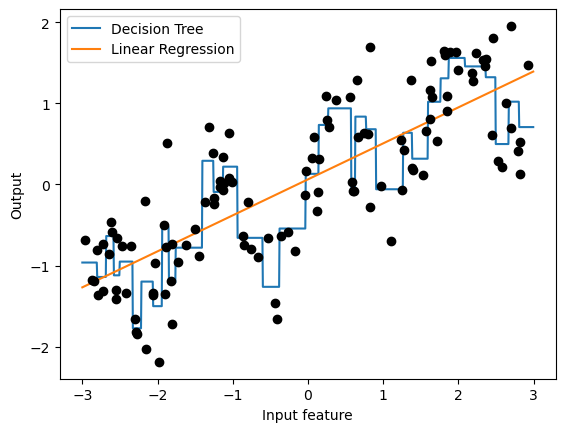

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X, y = mglearn.datasets.make_wave(n_samples=120)
line = np.linspace(-3,3,1000, endpoint=False).reshape(-1,1)

reg = DecisionTreeRegressor(min_samples_leaf=3).fit(X,y)
plt.plot(line, reg.predict(line), label='Decision Tree')

reg = LinearRegression().fit(X,y)
plt.plot(line, reg.predict(line), label='Linear Regression')

plt.plot(X[:,0], y, 'o', c='k')
plt.ylabel('Output')
plt.xlabel('Input feature')
plt.legend(loc='best')

> - 연속형 데이터에 아주 강력한 선형 모델을 만드는 방법 하나는 **한 특성을 여러 특성으로 나누는 구간 분할(bining, 이산화)임**
> - **구간 경계 정의**
>> - 균일한 너비로 (즉 구간의 경계 간의 거리가 동일하게) 하거나 데이터의 분위를 사용할 수 있음 (데이터 많은 구간 좁게)
>> - **KBinsDiscretizer** 클래스에 여러 방법들이 구현 되어 있음
>> - KBinDiscretizer는 한번에 여러개의 특성에 적용할 수 있음, *bin_edges_* 특성별로 경계값이 저장(numpy 배열)

In [4]:
from sklearn.preprocessing import KBinsDiscretizer

In [5]:
kb = KBinsDiscretizer(n_bins=10, strategy='uniform')
kb.fit(X)
print('bin edges: \n', kb.bin_edges_)

bin edges: 
 [array([-2.9668673 , -2.37804841, -1.78922951, -1.20041062, -0.61159173,
        -0.02277284,  0.56604605,  1.15486494,  1.74368384,  2.33250273,
         2.92132162])                                                   ]


> - ***transform* 메서드를 사용하면 각 데이터 포인트를 해당되는 구간으로 인코딩 할 수 있음**
> - **기본적으로 KBinsDiscretizer는 각 구간에 원-핫-인코딩을 적용, 구간마다 하나의 새로운 특성이 생기므로 희소행렬을 만듦** -> 구조 이해 필요

In [6]:
# 10개의 구간을 지정했기 때문에 변환된 데이터는 10차원이 됨
X_binned = kb.transform(X)
print(X_binned[:10])
print(X_binned.shape)

  (0, 3)	1.0
  (1, 9)	1.0
  (2, 7)	1.0
  (3, 6)	1.0
  (4, 1)	1.0
  (5, 1)	1.0
  (6, 0)	1.0
  (7, 8)	1.0
  (8, 6)	1.0
  (9, 7)	1.0
(120, 10)


In [7]:
# 희소 행렬을 밀집 배열로 변환하여 원본 데이터 포인트와 인코딩 결과를 비교
print(X[:10])
print(X_binned.toarray()[:10])

[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]
 [-2.06403288]
 [-2.65149833]
 [ 2.19705687]
 [ 0.60669007]
 [ 1.24843547]]
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


> - ***encode='ordinal'*** 로 설정하면 원-핫-인코딩된 구간의 인덱스를 바로 계산할 수 있지만 유용하지 않음
> - 해당 케이스에서는 예제를 간단하게 만들기 위해 ***encode='onehot-dense'*** 로 지정하여 원-핫-인코딩된 밀집 배열을 만들면 모든 특성을 바로 출력할 수 있음

In [8]:
kb = KBinsDiscretizer(n_bins=10, strategy='uniform', encode='onehot-dense') #toarray 메소드 불필요
kb.fit(X)
X_binned = kb.transform(X)

print(X_binned[:10])
print(X_binned.shape)

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
(120, 10)


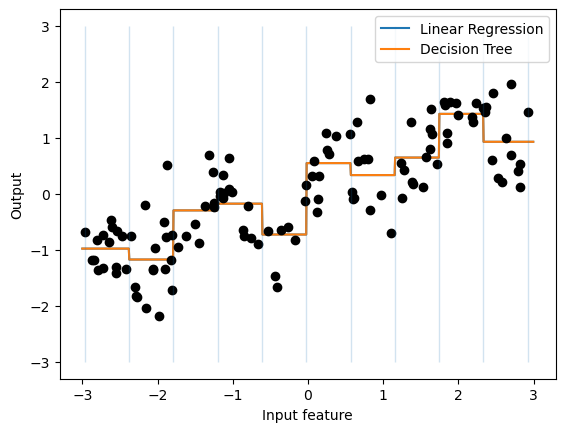

In [32]:
# 구간별 학습 도입
line_binned = kb.transform(line) # Predict를 돌리기 위한 특성 준비 개념

reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='Linear Regression')

reg = DecisionTreeRegressor(min_samples_split=3).fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='Decision Tree')

plt.plot(X[:,0], y, 'o', c='k')
plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=0.2)
plt.ylabel('Output')
plt.xlabel('Input feature')
plt.legend(loc='best')

- 선형 모델은 구간 분할을 통해 훨씬 유연해짐 vs 결정 트리는 유연성이 감소함
- 트리 모델은 알고리즘 특성 상 데이터를 자유롭게 나눠 학습할 수 있으므로 특성의 값을 구간으로 나누는 것의 이득이 없음
- 또한, 구간 분할은 특성마다 따로 진행 되어야 하지만 결정 트리는 한번에 여러 특성을 살필 수 있다는 차이가 있음 

## 4.5 상호작용과 다항식
- **특성을 풍부하게 나타내는 또 하나의 방법은 원본 데이터에 상호작용(interaction)과 다항식(polynomial)을 추가하는 것임**


- 위 예제에서는 특성이 어느 구간에 속하는지에 대한 정보와 각 포인트가 대응하는 상수값(y)에 대해 단순 학습하므로 구간 내 예측값이 일정 상수 값(절편)으로만 표현
- **기울기를 학습하기 위해서는 구간 분할 특성에 원래 특성(X)를 다시 추가하는 방법이 있음** -> 구간도 나눠주고 본연의 X값도 반영

In [10]:
X_combined = np.hstack([X, X_binned])
print(X_combined[:10])
print(X_combined.shape)

[[-0.75275929  0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.        ]
 [ 2.70428584  0.          0.          0.          0.          0.
   0.          0.          0.          0.          1.        ]
 [ 1.39196365  0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.        ]
 [ 0.59195091  0.          0.          0.          0.          0.
   0.          1.          0.          0.          0.        ]
 [-2.06388816  0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [-2.06403288  0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [-2.65149833  1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 2.19705687  0.          0.          0.          0.          0.
   0.          0.          0.  

In [11]:
line_combined = np.hstack([line, line_binned]) # Predict를 돌리기 위한 특성 준비 개념, 훈련에 사용한 X_combined와 같은 형태여야함
line_combined

array([[-3.   ,  1.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [-2.994,  1.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [-2.988,  1.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       ...,
       [ 2.982,  0.   ,  0.   , ...,  0.   ,  0.   ,  1.   ],
       [ 2.988,  0.   ,  0.   , ...,  0.   ,  0.   ,  1.   ],
       [ 2.994,  0.   ,  0.   , ...,  0.   ,  0.   ,  1.   ]])

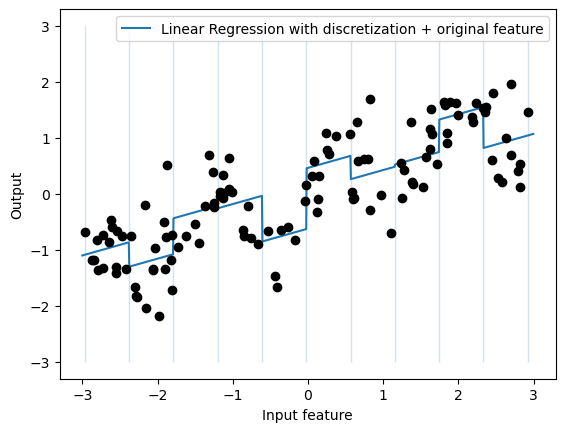

In [31]:
reg = LinearRegression().fit(X_combined, y)

plt.plot(line, reg.predict(line_combined), label='Linear Regression with discretization + original feature')

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=0.2)
plt.legend(loc='best')
plt.ylabel('Output')
plt.xlabel('Input feature')
plt.plot(X[:,0], y, 'o', c='k')

> - 이 모델은 각 구간의 절편과 전체 기울기를 학습, 학습된 기울기는 모든 구간에 걸쳐 동일함
> - **각 구간에서 다른 기울기를 가지게 하려면** 데이터 포인트가 있는 **구간과 x축 사이의 상호작용 특성 추가가 필요**
>> - = **구간 특성과 원본 특성의 곱**
>> - **해당 곱은 각 구간에 대한 x 축 특성의 복사본이라고 생각할 수 있음**
>> - **즉, 이 값은 구간 안에서는 원본 특성이고 다른 곳에서는 0이라는 의미를 가지게 됨**

In [13]:
X_product = np.hstack([X_binned, X*X_binned])

In [14]:
print(X_product)
print(X_product.shape)
# 이제 데이터 포인트가 속한 구간 정보와 이 구간에 원본 특성을 곱한 값을 더해 20개의 특성을 가짐

[[ 0.          0.          0.         ... -0.         -0.
  -0.        ]
 [ 0.          0.          0.         ...  0.          0.
   2.70428584]
 [ 0.          0.          0.         ...  1.39196365  0.
   0.        ]
 ...
 [ 0.          1.          0.         ... -0.         -0.
  -0.        ]
 [ 0.          0.          0.         ...  0.          0.
   2.35535399]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
(120, 20)


In [15]:
line_product = np.hstack([line_binned, line*line_binned]) # Predict를 돌리기 위한 특성 준비 개념
line_product

array([[ 1.   ,  0.   ,  0.   , ..., -0.   , -0.   , -0.   ],
       [ 1.   ,  0.   ,  0.   , ..., -0.   , -0.   , -0.   ],
       [ 1.   ,  0.   ,  0.   , ..., -0.   , -0.   , -0.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  2.982],
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  2.988],
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  2.994]])

Text(0.5, 0, 'Input feature')

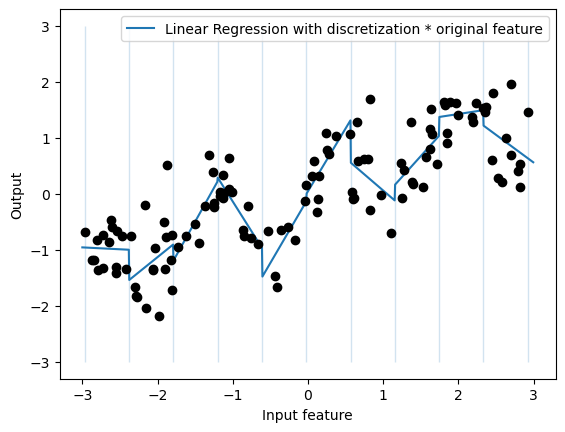

In [30]:
reg = LinearRegression().fit(X_product, y)

plt.plot(line, reg.predict(line_product), label='Linear Regression with discretization * original feature')

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=0.2)

plt.plot(X[:,0], y, 'o', c='k')
plt.legend(loc='best')
plt.ylabel('Output')
plt.xlabel('Input feature')

> - **원본 특성의 다항식을 추가하는 방법도 있으며, 해당 방식은 preprocessing 모듈의 PolynomialFeatures에 구현되어 있음**
> - 선형 모델이 아닌 트리기반의 복잡한 모델을 사용할 경우에는 다항 특성을 추가하는 것이 반드시 성능향상으로 이어지지는 않음

In [17]:
from sklearn.preprocessing import PolynomialFeatures

In [18]:
# X**10까지 고차항을 추가
# 기본값인 "include_bias=True"는 절편에 해당하는 1인 특성을 추가
poly = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(X)
X_poly = poly.transform(X)

X_poly.shape

(120, 10)

In [20]:
print(X[:5])
print(X_poly[:5])

[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
[[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]


> - 각 특성의 차수를 알려주는 *get_feature_names_out* 메서드를 사용해 **특성의 의미를 알 수 있음**
> - 2개 이상 특성을 고려할 때 매개변수 ***interaction_only=True*로 설정하면 단일 특성의 거듭제곱이 포함된 항은 모두 제외**
> - 다항식 특성을 선형 모델과 함께 사용하면 전형적인 **다항회귀(polynomial regression) 모델이 됨**

In [38]:
poly.get_feature_names_out()

array(['x0', 'x0^2', 'x0^3', 'x0^4', 'x0^5', 'x0^6', 'x0^7', 'x0^8',
       'x0^9', 'x0^10'], dtype=object)

Text(0.5, 0, 'Input feature')

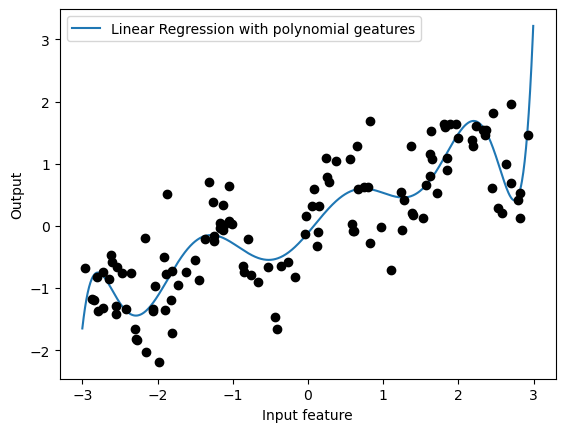

In [29]:
reg = LinearRegression().fit(X_poly, y)

line_poly = poly.transform(line)

plt.plot(line, reg.predict(line_poly), label='Linear Regression with polynomial geatures')

plt.plot(X[:,0], y, 'o', c='k')
plt.legend(loc='best')
plt.ylabel('Output')
plt.xlabel('Input feature')

- 다항식 특성은 1차원 데이터셋에서도 매우 부드러운 곡선을 만들어주지만, **고차원 다항식은 데이터가 부족한 영역에서 너무 민감하게 동작**

> - 비교를 위해 아무런 변화도 거치지 않은 원본 데이터에 커널 SVM 모델을 학습

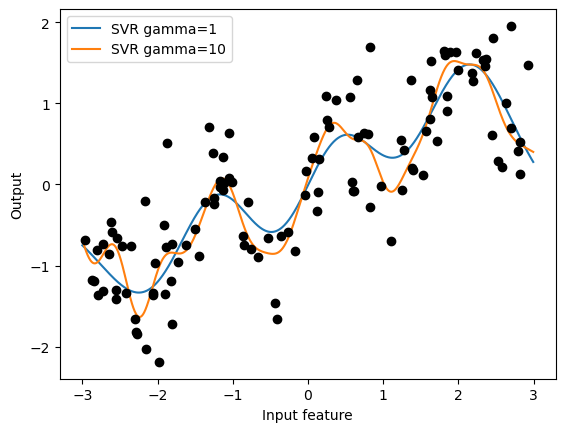

In [34]:
from sklearn.svm import SVR

for gamma in [1,10]:
    svr = SVR(gamma=gamma).fit(X,y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma)) # 기본값인 RBF 커널
    
plt.plot(X[:,0], y, 'o', c='k')
plt.ylabel('Output')
plt.xlabel('Input feature')
plt.legend(loc='best')